# Computing the PCA of a Foreground Object
We show in our paper many figures with object parts colored like rainbows. These visualizations are obtained by computing a PCA of patch features on the foreground object. This is what we will compute in this tutorial! Let's start by loading some pre-requisites.

### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:
- `local` if `DINOV3_LOCATION` environment variable was set to work with a local version of DINOv3 repository;
- `github` if the code should be loaded via torch hub.

#### Installation Requirements

For the pathology workflow, you need additional dependencies:

```bash
# Install via micromamba
micromamba install h5py opencv geopandas

# Install via pip (not available in micromamba)
pip install openslide-python
```

See `requirements-pathology.txt` for full details.

In [17]:
import pickle
import os
import urllib
import sys
from typing import Tuple, Dict, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import h5py

import torch
import torchvision.transforms.functional as TF
from sklearn.decomposition import PCA
from scipy import signal

# Add trident to path for using its WSI loaders
TRIDENT_PATH = "/home/nadim/Source/trident"
if TRIDENT_PATH not in sys.path:
    sys.path.insert(0, TRIDENT_PATH)

DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")
print(f"Trident path: {TRIDENT_PATH}")
print(f"h5py version: {h5py.__version__}")

DINOv3 location set to facebookresearch/dinov3
Trident path: /home/nadim/Source/trident
h5py version: 3.15.1


### Model Loading
We load the DINOv3 ViT-L model. Feel free to try other DINOv3 models as well!

In [ ]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITHP  # Using ViT-H16+ to match the checkpoint

# Load model from local checkpoint
CHECKPOINT_PATH = "/home/nadim/Downloads/dinov3h16/dinov3_vith16plus_pretrain_lvd1689m-7c1da9a5.pth"

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model=MODEL_NAME,
    source="local" if DINOV3_LOCATION != DINOV3_GITHUB_LOCATION else "github",
    pretrained=True,
    weights=CHECKPOINT_PATH,  # Pass the local file path as weights
)
model.cuda()

Using cache found in /home/nadim/.cache/torch/hub/facebookresearch_dinov3_main


### Loading the Foreground Classifier from the Other Tutorial
For this tutorial, we use the classifier trained in the `foreground_segmentation` notebook. If you haven't already, have a look! Once you have trained your foreground / background classifier on patch features, you should be able to load it here. 

---
## Pathology Feature Loading from Trident H5 Files

The following cells implement functionality to load pre-extracted features and coordinates from Trident-processed pathology slides.

In [ ]:
def load_h5_from_trident(h5_path: str) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """
    Load patch coordinates and features from a Trident-generated H5 file.
    
    Parameters
    ----------
    h5_path : str
        Path to the H5 file containing coords and features
        
    Returns
    -------
    coords : np.ndarray
        Array of patch coordinates (N, 2) where N is number of patches
    features : np.ndarray
        Array of feature vectors (N, D) where D is feature dimension
    metadata : dict
        Dictionary containing H5 file metadata and attributes
        
    Examples
    --------
    >>> coords, features, metadata = load_h5_from_trident("path/to/slide.h5")
    >>> print(f"Loaded {len(coords)} patches with {features.shape[1]}-dim features")
    """
    with h5py.File(h5_path, 'r') as f:
        # Load coords and features
        coords = f['coords'][:]
        features = f['features'][:]
        
        # Extract metadata from attributes
        metadata = {}
        for key in ['coords', 'features']:
            if key in f and hasattr(f[key], 'attrs'):
                metadata[key] = dict(f[key].attrs)
        
        # Add file-level info
        metadata['h5_keys'] = list(f.keys())
        metadata['num_patches'] = len(coords)
        metadata['feature_dim'] = features.shape[1] if len(features.shape) > 1 else 1
        
    return coords, features, metadata

### Test Feature 2: Load H5 from Trident

In [ ]:
# Test loading a sample H5 file
TEST_H5_PATH = "/media/nadim/Data/prostate-cancer-grade-assessment/trident_processedqc/20x_256px_0px_overlap/features_uni_v2/0005f7aaab2800f6170c399693a96917.h5"

print("Testing load_h5_from_trident()...")
coords, features, metadata = load_h5_from_trident(TEST_H5_PATH)

print(f"\n✓ Successfully loaded H5 file")
print(f"  Coordinates shape: {coords.shape}")
print(f"  Features shape: {features.shape}")
print(f"  Number of patches: {metadata['num_patches']}")
print(f"  Feature dimension: {metadata['feature_dim']}")
print(f"  H5 keys: {metadata['h5_keys']}")

# Display first few coordinates
print(f"\n  First 5 patch coordinates:")
for i in range(min(5, len(coords))):
    print(f"    Patch {i}: {coords[i]}")
    
# Feature statistics
print(f"\n  Feature statistics:")
print(f"    Mean: {features.mean():.4f}")
print(f"    Std: {features.std():.4f}")
print(f"    Min: {features.min():.4f}")
print(f"    Max: {features.max():.4f}")

Testing load_h5_from_trident()...

✓ Successfully loaded H5 file
  Coordinates shape: (534, 2)
  Features shape: (534, 1536)
  Number of patches: 534
  Feature dimension: 1536
  H5 keys: ['coords', 'features']

  First 5 patch coordinates:
    Patch 0: [3328 3328]
    Patch 1: [3328 3584]
    Patch 2: [3328 3840]
    Patch 3: [3328 4096]
    Patch 4: [3328 4352]

  Feature statistics:
    Mean: 0.0047
    Std: 0.4674
    Min: -4.4462
    Max: 2.6500


In [ ]:
def load_wsi_and_extract_patches(
    wsi_path: str, 
    coords: np.ndarray, 
    patch_size: int = 256,
    target_mag: int = 20
) -> Tuple[list, Dict]:
    """
    Load a whole-slide image and extract patches at specified coordinates using Trident.
    
    Parameters
    ----------
    wsi_path : str
        Path to the WSI file (.tiff, .svs, etc.)
    coords : np.ndarray
        Array of patch coordinates (N, 2) at level 0
    patch_size : int
        Size of patches to extract (default: 256)
    target_mag : int
        Target magnification for extraction (default: 20x)
        
    Returns
    -------
    patches : list
        List of PIL Image patches
    wsi_info : dict
        Dictionary containing WSI metadata (dimensions, magnification, etc.)
        
    Examples
    --------
    >>> patches, info = load_wsi_and_extract_patches("slide.tiff", coords)
    >>> print(f"Extracted {len(patches)} patches from {info['filename']}")
    """
    # Import from top-level trident to avoid circular imports
    from trident import load_wsi
    
    # Load WSI using trident factory - disable lazy_init to load immediately
    wsi = load_wsi(wsi_path, lazy_init=False)
    
    # Store WSI info
    wsi_info = {
        'filename': os.path.basename(wsi_path),
        'width': wsi.width,
        'height': wsi.height,
        'magnification': wsi.mag,
        'num_coords': len(coords),
        'patch_size': patch_size,
        'target_mag': target_mag
    }
    
    # Create patcher with the given coordinates
    # Set pil=True to return PIL Images instead of numpy arrays
    patcher = wsi.create_patcher(
        patch_size=patch_size,
        src_mag=wsi.mag,
        dst_mag=target_mag,
        custom_coords=coords,
        coords_only=False,  # We want to extract actual patches
        pil=True  # Return PIL Images (not numpy arrays)
    )
    
    # Extract all patches
    patches = []
    for i, (patch, x, y) in enumerate(patcher):
        patches.append(patch)
        
    print(f"Extracted {len(patches)} patches from {wsi_info['filename']}")
    
    return patches, wsi_info

### Test Feature 3: Load WSI and Extract Patches

Testing load_wsi_and_extract_patches()...
Extracted 10 patches from 0005f7aaab2800f6170c399693a96917.tiff

✓ Successfully extracted patches
  WSI filename: 0005f7aaab2800f6170c399693a96917.tiff
  WSI dimensions: 27648 x 29440
  WSI magnification: 20x
  Number of patches extracted: 10
  Patch size: (256, 256)


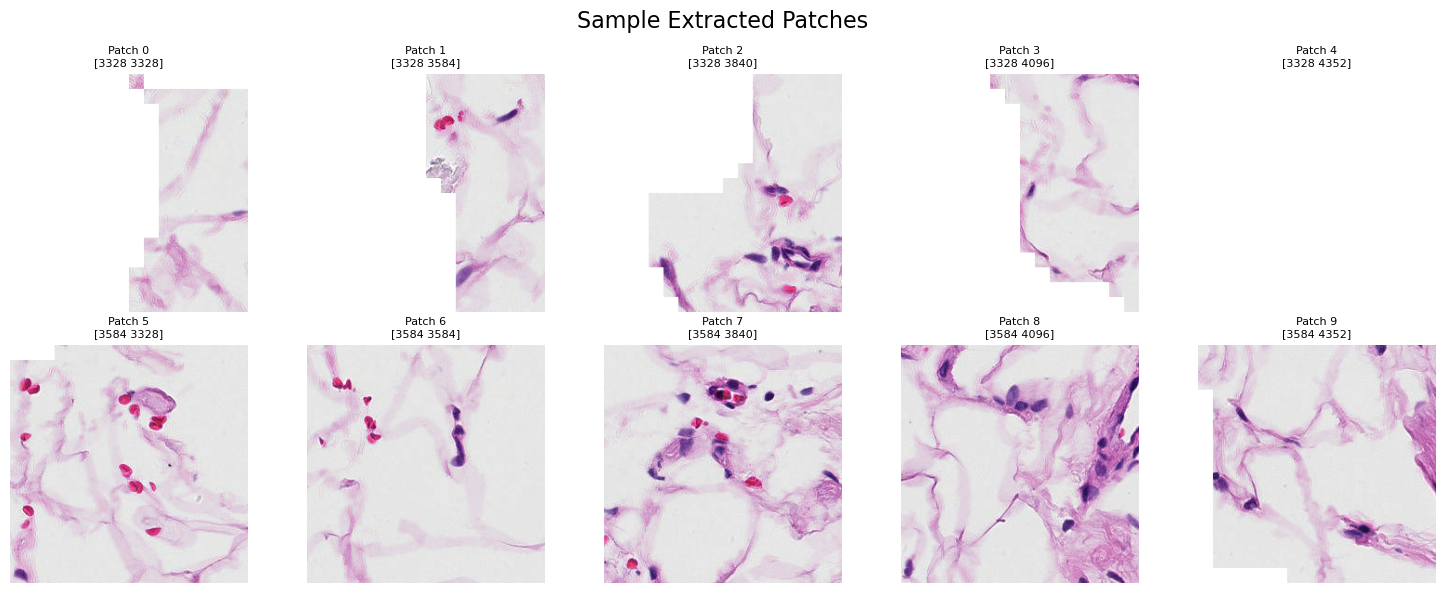


✓ Feature 3 test completed successfully!


In [ ]:
# Test loading WSI and extracting patches
TEST_WSI_PATH = "/media/nadim/Data/prostate-cancer-grade-assessment/train_images/0005f7aaab2800f6170c399693a96917.tiff"

print("Testing load_wsi_and_extract_patches()...")

# Extract first 10 patches as a test (to avoid loading all patches)
test_coords = coords[:10]
patches, wsi_info = load_wsi_and_extract_patches(
    TEST_WSI_PATH, 
    test_coords, 
    patch_size=256, 
    target_mag=20
)

print(f"\n✓ Successfully extracted patches")
print(f"  WSI filename: {wsi_info['filename']}")
print(f"  WSI dimensions: {wsi_info['width']} x {wsi_info['height']}")
print(f"  WSI magnification: {wsi_info['magnification']}x")
print(f"  Number of patches extracted: {len(patches)}")
print(f"  Patch size: {patches[0].size if patches else 'N/A'}")

# Visualize first few patches
if patches:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle("Sample Extracted Patches", fontsize=16)
    
    for idx, (ax, patch) in enumerate(zip(axes.flat, patches)):
        ax.imshow(patch)
        ax.set_title(f"Patch {idx}\n{coords[idx]}", fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
print("\n✓ Feature 3 test completed successfully!")

---
## Pathology PCA Workflow

Now we'll apply the PCA visualization to our pathology patches. Since the patches are already 256x256 and pre-segmented:
1. Normalize patches to ImageNet mean/std
2. Compute DINOv3 features (each 256x256 patch → 16x16 = 256 patch features)
3. Fit PCA on all patch features
4. Visualize with rainbow colors

In [ ]:
# Load all patches from the WSI (not just the first 10)
print("Loading all patches from WSI...")
all_patches, wsi_info = load_wsi_and_extract_patches(
    TEST_WSI_PATH, 
    coords,  # Use all coords
    patch_size=256, 
    target_mag=20
)

print(f"\nLoaded {len(all_patches)} patches total")
print(f"Patch dimensions: {all_patches[0].size}")

# Normalize patches to ImageNet mean/std
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Convert PIL images to tensors and normalize
normalized_patches = []
for patch in all_patches:
    # Convert to tensor and normalize
    patch_tensor = TF.to_tensor(patch)
    patch_normalized = TF.normalize(patch_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
    normalized_patches.append(patch_normalized)

# Stack into a batch
patches_batch = torch.stack(normalized_patches)
print(f"\nNormalized patches batch shape: {patches_batch.shape}")
print(f"Expected: [num_patches={len(all_patches)}, channels=3, height=256, width=256]")

Loading all patches from WSI...
Extracted 534 patches from 0005f7aaab2800f6170c399693a96917.tiff

Loaded 534 patches total
Patch dimensions: (256, 256)

Normalized patches batch shape: torch.Size([534, 3, 256, 256])
Expected: [num_patches=534, channels=3, height=256, width=256]


### Compute DINOv3 Features on Pathology Patches

Extract features from all patches using the DINOv3 model. Each 256x256 patch produces 16x16 = 256 patch-level features.

In [ ]:
# Constants for the model
PATCH_SIZE = 16  # ViT patch size
MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}
n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

# Compute features for all patches
print(f"Computing DINOv3 features for {len(all_patches)} patches...")
print(f"Using {n_layers} layers from {MODEL_NAME}")

all_features = []

# Process in batches to avoid OOM
batch_size = 32
num_batches = (len(all_patches) + batch_size - 1) // batch_size

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min((i + 1) * batch_size, len(all_patches))
            
            batch = patches_batch[start_idx:end_idx].cuda()
            
            # Get features from last layer
            feats = model.get_intermediate_layers(
                batch, 
                n=range(n_layers), 
                reshape=True, 
                norm=True
            )
            
            # Extract last layer features
            batch_feats = feats[-1].detach().cpu()
            all_features.append(batch_feats)
            
            if (i + 1) % 10 == 0 or (i + 1) == num_batches:
                print(f"  Processed {end_idx}/{len(all_patches)} patches")

# Concatenate all features
all_features = torch.cat(all_features, dim=0)

print(f"\nFeature extraction complete!")
print(f"  Features shape: {all_features.shape}")
print(f"  Expected: [num_patches={len(all_patches)}, feature_dim=1280, h=16, w=16]")

Computing DINOv3 features for 534 patches...
Using 32 layers from dinov3_vith16plus
  Processed 320/534 patches
  Processed 534/534 patches

Feature extraction complete!
  Features shape: torch.Size([534, 1280, 16, 16])
  Expected: [num_patches=534, feature_dim=1280, h=16, w=16]


### Reshape Features for PCA

Reshape features from [num_patches, feature_dim, h, w] to [num_patches * h * w, feature_dim] to prepare for PCA fitting.

In [ ]:
# Reshape features for PCA
# From [num_patches, feature_dim, h, w] to [num_patches, h, w, feature_dim]
# Then flatten spatial dimensions to [num_patches * h * w, feature_dim]

num_patches, feature_dim, h, w = all_features.shape

# Reshape to [num_patches, h, w, feature_dim]
features_reshaped = all_features.permute(0, 2, 3, 1)

# Flatten to [num_patches * h * w, feature_dim]
features_flat = features_reshaped.reshape(-1, feature_dim)

print(f"Reshaped features for PCA:")
print(f"  Original shape: {all_features.shape}")
print(f"  Flattened shape: {features_flat.shape}")
print(f"  Total patch features: {num_patches} patches × {h}×{w} = {features_flat.shape[0]}")

Reshaped features for PCA:
  Original shape: torch.Size([534, 1280, 16, 16])
  Flattened shape: torch.Size([136704, 1280])
  Total patch features: 534 patches × 16×16 = 136704


### Fit PCA on All Pathology Features

Fit PCA with 3 components (for RGB visualization) on all patch features.

In [ ]:
# Fit PCA with 3 components for RGB visualization
print("Fitting PCA on pathology features...")
pca_pathology = PCA(n_components=3, whiten=True)
pca_pathology.fit(features_flat.numpy())

print(f"\n✓ PCA fitted successfully!")
print(f"  Explained variance ratio: {pca_pathology.explained_variance_ratio_}")
print(f"  Total variance explained: {pca_pathology.explained_variance_ratio_.sum():.4f}")

Fitting PCA on pathology features...

✓ PCA fitted successfully!
  Explained variance ratio: [0.22321461 0.07337823 0.06271684]
  Total variance explained: 0.3593


### Apply PCA and Visualize Rainbow Patches

Transform features with PCA and create rainbow-colored visualizations for each patch.

In [ ]:
# Apply PCA transformation
print("Applying PCA transformation...")
pca_features = pca_pathology.transform(features_flat.numpy())

# Reshape back to [num_patches, h, w, 3]
pca_features_reshaped = pca_features.reshape(num_patches, h, w, 3)

# Convert to torch tensor
pca_features_tensor = torch.from_numpy(pca_features_reshaped)

# Apply sigmoid with scaling for vibrant colors
# Multiply by 2.0 and pass through sigmoid to get vibrant colors
pca_rgb = torch.nn.functional.sigmoid(pca_features_tensor.mul(2.0))

# Permute to [num_patches, 3, h, w] for visualization
pca_rgb = pca_rgb.permute(0, 3, 1, 2)

print(f"\n✓ PCA transformation complete!")
print(f"  PCA RGB shape: {pca_rgb.shape}")
print(f"  Expected: [num_patches={num_patches}, channels=3, h={h}, w={w}]")

Applying PCA transformation...

✓ PCA transformation complete!
  PCA RGB shape: torch.Size([534, 3, 16, 16])
  Expected: [num_patches=534, channels=3, h=16, w=16]


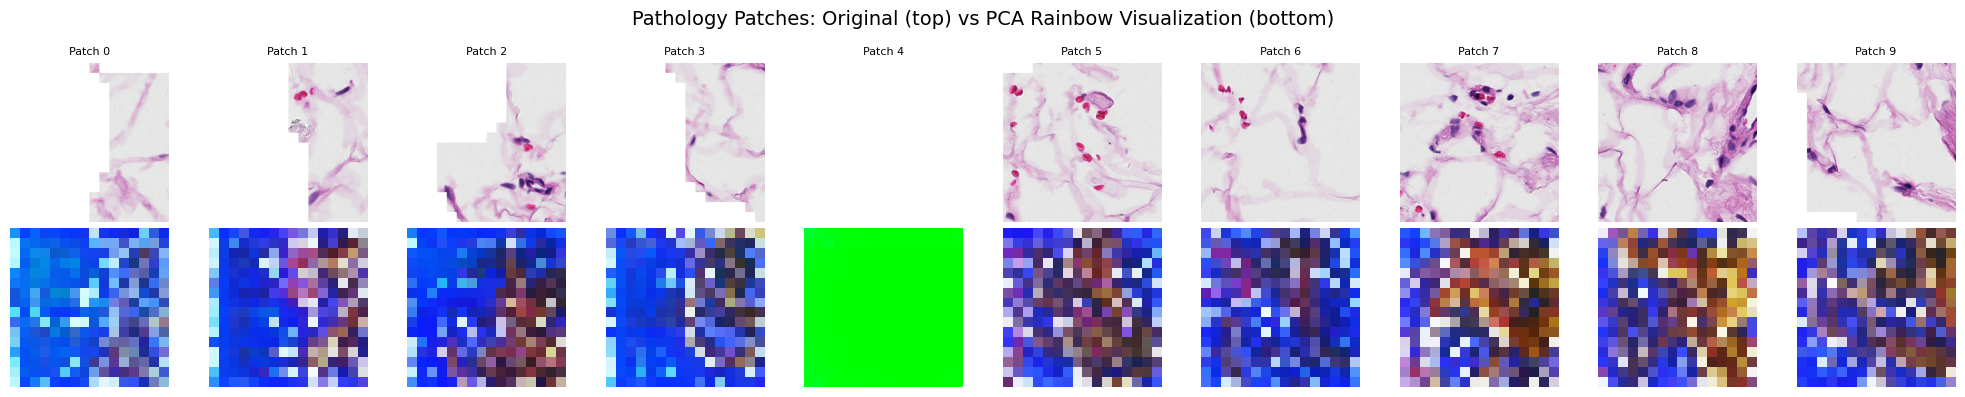


✓ Visualized 10 sample patches with PCA rainbow colors!


In [ ]:
# Visualize sample patches with their PCA rainbow colors
num_samples = min(10, num_patches)

fig, axes = plt.subplots(2, num_samples, figsize=(20, 4))
fig.suptitle("Pathology Patches: Original (top) vs PCA Rainbow Visualization (bottom)", fontsize=14)

for i in range(num_samples):
    # Original patch
    axes[0, i].imshow(all_patches[i])
    axes[0, i].axis('off')
    axes[0, i].set_title(f"Patch {i}", fontsize=8)
    
    # PCA rainbow visualization
    pca_img = pca_rgb[i].permute(1, 2, 0).numpy()
    axes[1, i].imshow(pca_img)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ Visualized {num_samples} sample patches with PCA rainbow colors!")

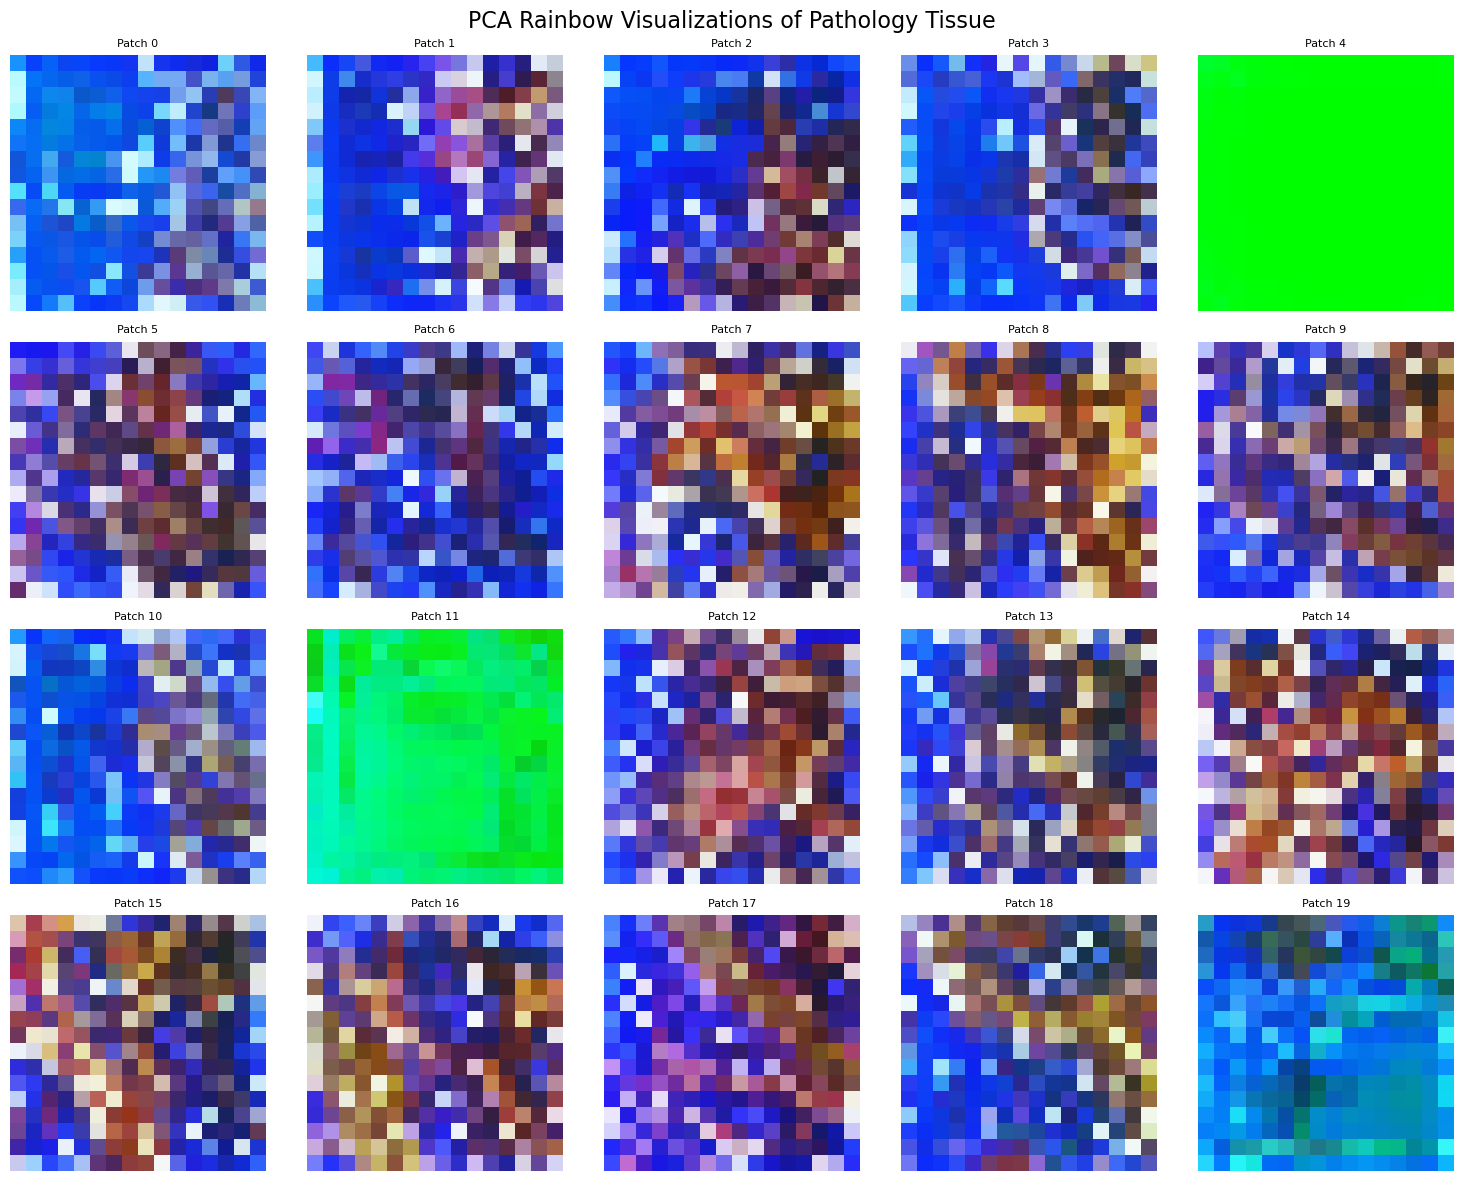

In [ ]:
# Display a larger grid of PCA rainbow visualizations
num_display = min(20, num_patches)
rows = 4
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
fig.suptitle("PCA Rainbow Visualizations of Pathology Tissue", fontsize=16)

for idx in range(num_display):
    row = idx // cols
    col = idx % cols
    
    pca_img = pca_rgb[idx].permute(1, 2, 0).numpy()
    axes[row, col].imshow(pca_img)
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Patch {idx}", fontsize=8)

# Turn off any unused subplots
for idx in range(num_display, rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

---
## Overlay Visualizations (Inspired by prov-gigapath)

Now let's create overlay visualizations by blending the PCA rainbow colors with the original patches.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def create_overlay_patch(original_patch, pca_result, alpha=0.3):
    """
    Create an overlay of PCA result on original patch.
    
    Parameters
    ----------
    original_patch : PIL.Image or np.ndarray
        Original patch image (256x256)
    pca_result : np.ndarray
        PCA result (16x16x3) in [0, 1] range
    alpha : float
        Blending factor (0=full PCA, 1=full original)
        Default 0.3 means 30% original + 70% PCA
        
    Returns
    -------
    overlay : np.ndarray
        Overlaid image (256x256x3) as uint8
    """
    # Convert PIL to numpy if needed
    if hasattr(original_patch, 'size'):
        original_np = np.array(original_patch)
    else:
        original_np = original_patch
    
    # Resize PCA result from 16x16 to 256x256 to match original
    # Use PIL Image for resizing instead of cv2
    pca_pil = Image.fromarray((pca_result * 255).astype(np.uint8))
    pca_resized_pil = pca_pil.resize((original_np.shape[1], original_np.shape[0]), Image.BILINEAR)
    pca_resized = np.array(pca_resized_pil).astype(np.float32) / 255.0
    
    # Blend: alpha * original + (1-alpha) * PCA * 255
    overlay = (alpha * original_np + (1 - alpha) * pca_resized * 255).astype(np.uint8)
    
    return overlay

print("✓ Overlay function defined (using PIL resize)")

AttributeError: module 'cv2' has no attribute 'resize'

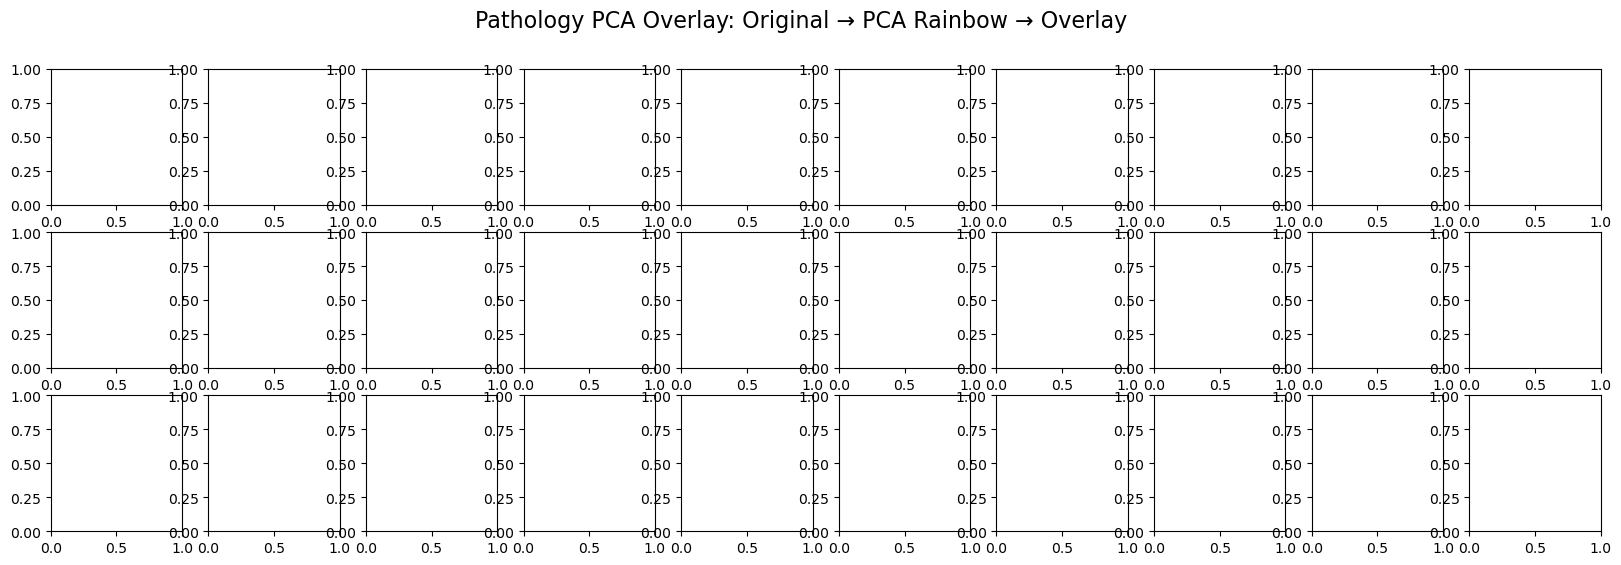

In [ ]:
# Create overlay visualizations for sample patches
num_samples = min(10, num_patches)

fig, axes = plt.subplots(3, num_samples, figsize=(20, 6))
fig.suptitle("Pathology PCA Overlay: Original → PCA Rainbow → Overlay", fontsize=16)

for i in range(num_samples):
    # Get PCA result for this patch (convert from CHW to HWC)
    pca_result = pca_rgb[i].permute(1, 2, 0).numpy()  # Shape: (16, 16, 3)
    
    # Create overlay
    overlay = create_overlay_patch(all_patches[i], pca_result, alpha=0.3)
    
    # Row 0: Original patch
    axes[0, i].imshow(all_patches[i])
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12, rotation=0, ha='right', va='center')
    
    # Row 1: PCA rainbow
    axes[1, i].imshow(pca_result)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('PCA Rainbow', fontsize=12, rotation=0, ha='right', va='center')
    
    # Row 2: Overlay
    axes[2, i].imshow(overlay)
    axes[2, i].axis('off')
    axes[2, i].set_title(f"Patch {i}", fontsize=8)
    if i == 0:
        axes[2, i].set_ylabel('Overlay (30/70)', fontsize=12, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

print(f"✓ Created overlay visualizations for {num_samples} patches")

### Individual PCA Component Visualization

Visualize each PCA component separately using colormaps to understand what each component captures.

In [ ]:
# Visualize individual PCA components
num_samples = min(5, num_patches)

fig, axes = plt.subplots(num_samples, 4, figsize=(12, 3 * num_samples))

# Handle single patch case
if num_samples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples):
    # Original patch
    axes[i, 0].imshow(all_patches[i])
    axes[i, 0].set_title(f"Original Patch {i}", fontsize=10)
    axes[i, 0].axis('off')
    
    # PCA Component 1 (Red channel)
    component1 = pca_rgb[i][0].numpy()  # Shape: (16, 16)
    im1 = axes[i, 1].imshow(component1, cmap='Reds', vmin=0, vmax=1)
    axes[i, 1].set_title(f"PCA Component 1", fontsize=10)
    axes[i, 1].axis('off')
    
    # PCA Component 2 (Green channel)
    component2 = pca_rgb[i][1].numpy()  # Shape: (16, 16)
    im2 = axes[i, 2].imshow(component2, cmap='Greens', vmin=0, vmax=1)
    axes[i, 2].set_title(f"PCA Component 2", fontsize=10)
    axes[i, 2].axis('off')
    
    # PCA Component 3 (Blue channel)
    component3 = pca_rgb[i][2].numpy()  # Shape: (16, 16)
    im3 = axes[i, 3].imshow(component3, cmap='Blues', vmin=0, vmax=1)
    axes[i, 3].set_title(f"PCA Component 3", fontsize=10)
    axes[i, 3].axis('off')

fig.suptitle('Individual PCA Components (RGB Channels)', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

print(f"✓ Visualized individual components for {num_samples} patches")

### Large Overlay Grid

Display a larger grid showing original patches alongside their overlays.

In [ ]:
# Create a large grid of overlays
num_display = min(20, num_patches)
rows = 5
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(16, 20))
fig.suptitle("PCA Feature Overlays on Pathology Patches (30% original / 70% PCA)", fontsize=16)

for idx in range(num_display):
    row = idx // cols
    col = idx % cols
    
    # Get PCA result and create overlay
    pca_result = pca_rgb[idx].permute(1, 2, 0).numpy()
    overlay = create_overlay_patch(all_patches[idx], pca_result, alpha=0.3)
    
    axes[row, col].imshow(overlay)
    axes[row, col].axis('off')
    axes[row, col].set_title(f"Patch {idx}", fontsize=9)

# Turn off unused subplots
for idx in range(num_display, rows * cols):
    row = idx // cols
    col = idx % cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"✓ Displayed {num_display} overlay patches in grid")

### Exploring Different Overlay Alpha Values

Compare different blending ratios to find the optimal balance between original tissue and PCA features.

In [ ]:
# Compare different alpha values on a single patch
sample_idx = 0  # Choose first patch
alpha_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle(f"Overlay Blending: Different Alpha Values (Patch {sample_idx})", fontsize=14)

pca_result = pca_rgb[sample_idx].permute(1, 2, 0).numpy()

for idx, alpha in enumerate(alpha_values):
    row = idx // 3
    col = idx % 3
    
    if alpha == 1.0:
        # Show original image
        axes[row, col].imshow(all_patches[sample_idx])
        title = f"α={alpha} (100% Original)"
    elif alpha == 0.0:
        # Show full PCA (resize using PIL)
        pca_pil = Image.fromarray((pca_result * 255).astype(np.uint8))
        pca_resized = np.array(pca_pil.resize((256, 256), Image.BILINEAR)).astype(np.float32) / 255.0
        axes[row, col].imshow(pca_resized)
        title = f"α={alpha} (100% PCA)"
    else:
        # Show overlay
        overlay = create_overlay_patch(all_patches[sample_idx], pca_result, alpha=alpha)
        axes[row, col].imshow(overlay)
        title = f"α={alpha} ({int(alpha*100)}% Orig / {int((1-alpha)*100)}% PCA)"
    
    axes[row, col].set_title(title, fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("✓ Compared different alpha blending values")

### High-Resolution PCA Components (Upsampled to 256x256)

Upsample the PCA components from 16x16 to 256x256 to match the original patch resolution.

In [ ]:
from matplotlib.colors import ListedColormap

# Create custom colormap with black background for zero values (like prov-gigapath)
viridis_with_black = plt.cm.viridis(np.linspace(0, 1, 256))
viridis_with_black[0] = [0, 0, 0, 1]  # Set first color to black
custom_cmap = ListedColormap(viridis_with_black)

# Visualize upsampled components
num_samples = min(3, num_patches)

fig, axes = plt.subplots(num_samples, 5, figsize=(15, 3 * num_samples))

# Handle single patch case
if num_samples == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples):
    # Original patch
    axes[i, 0].imshow(all_patches[i])
    axes[i, 0].set_title(f"Original Patch {i}", fontsize=10)
    axes[i, 0].axis('off')
    
    # Upsample each component to 256x256 using PIL
    for comp_idx in range(3):
        component = pca_rgb[i][comp_idx].numpy()  # (16, 16)
        
        # Convert to PIL Image and resize
        comp_pil = Image.fromarray((component * 255).astype(np.uint8))
        comp_upsampled = np.array(comp_pil.resize((256, 256), Image.BILINEAR)).astype(np.float32) / 255.0
        
        # Show with viridis colormap
        im = axes[i, comp_idx + 1].imshow(comp_upsampled, cmap='viridis', vmin=0, vmax=1)
        axes[i, comp_idx + 1].set_title(f"Component {comp_idx + 1}", fontsize=10)
        axes[i, comp_idx + 1].axis('off')
    
    # Combined RGB (upsampled)
    pca_result = pca_rgb[i].permute(1, 2, 0).numpy()
    pca_pil = Image.fromarray((pca_result * 255).astype(np.uint8))
    pca_upsampled = np.array(pca_pil.resize((256, 256), Image.BILINEAR)).astype(np.float32) / 255.0
    axes[i, 4].imshow(pca_upsampled)
    axes[i, 4].set_title("Combined RGB", fontsize=10)
    axes[i, 4].axis('off')

fig.suptitle('Upsampled PCA Components (16x16 → 256x256)', fontsize=16, y=1.0)
plt.tight_layout()
plt.show()

print(f"✓ Visualized upsampled components for {num_samples} patches")

---
## Summary

This notebook demonstrates the complete pathology PCA workflow:

1. **Data Loading**: Load pre-extracted features and coordinates from Trident H5 files
2. **Patch Extraction**: Extract tissue patches from whole-slide images using Trident
3. **Feature Computation**: Compute DINOv3 features on pathology patches
4. **PCA Fitting**: Fit 3-component PCA on all tissue features
5. **Visualization Techniques**:
   - Rainbow PCA visualizations
   - Overlay blending (original + PCA features)
   - Individual component analysis
   - Multi-alpha comparison
   - High-resolution upsampling

**Key Techniques (inspired by prov-gigapath):**
- `PIL.Image.resize()` for upsampling PCA from 16x16 to 256x256
- Alpha blending: `alpha * original + (1-alpha) * pca * 255`
- Component-wise visualization with colormaps
- Custom colormap with black background

---
## Interactive ROI Selection

Load the WSI at lower magnification (10x) to get an overview, then interactively select regions of interest to examine specific patches.

### Load WSI Overview at 10x Magnification

Load a lower resolution version of the WSI to see the overall tissue structure.

In [ ]:
from trident import load_wsi

# Load WSI for overview
print("Loading WSI for overview...")
wsi = load_wsi(TEST_WSI_PATH, lazy_init=False)

print(f"WSI Info:")
print(f"  Dimensions: {wsi.width} x {wsi.height}")
print(f"  Native magnification: {wsi.mag}x")

# Get overview at 10x magnification
overview_mag = 10
overview_scale = overview_mag / wsi.mag

# Calculate overview dimensions
overview_width = int(wsi.width * overview_scale)
overview_height = int(wsi.height * overview_scale)

print(f"\nOverview at {overview_mag}x:")
print(f"  Dimensions: {overview_width} x {overview_height}")
print(f"  Scale factor: {overview_scale:.4f}")

# Read the overview thumbnail
# Use get_thumbnail or read_region at appropriate level
overview_img = wsi.read_region((0, 0), wsi.mag, overview_mag, (wsi.width, wsi.height))

print(f"  Overview image size: {overview_img.size}")

# Display overview with existing patches marked
fig, ax = plt.subplots(1, 1, figsize=(16, 16))
ax.imshow(overview_img)
ax.set_title(f"WSI Overview at {overview_mag}x - {wsi_info['filename']}", fontsize=14)

# Plot existing patch locations (scaled to 10x)
patch_coords_scaled = coords * overview_scale
ax.scatter(patch_coords_scaled[:, 0], patch_coords_scaled[:, 1], 
           c='red', s=5, alpha=0.5, marker='s', label=f'{len(coords)} patches (20x)')

ax.legend()
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"\n✓ Loaded WSI overview with {len(coords)} existing patches marked")

### Interactive ROI Selection Tool

Click on the image to select rectangular regions of interest. Click two points to define each ROI (top-left and bottom-right corners).

In [ ]:
from matplotlib.patches import Rectangle

class ROISelector:
    """Interactive ROI selector for WSI overview."""
    
    def __init__(self, img, max_rois=10):
        self.img = img
        self.max_rois = max_rois
        self.rois = []  # List of (x1, y1, x2, y2) tuples
        self.current_point = None
        self.rectangles = []
        
        # Create figure
        self.fig, self.ax = plt.subplots(1, 1, figsize=(16, 16))
        self.ax.imshow(self.img)
        self.ax.set_title(f"Click to select ROIs (0/{max_rois})\nClick 2 points to define each ROI rectangle", 
                         fontsize=14)
        self.ax.axis('off')
        
        # Connect click event
        self.cid = self.fig.canvas.mpl_connect('button_press_event', self.on_click)
        
        plt.tight_layout()
        
    def on_click(self, event):
        """Handle mouse click events."""
        if event.inaxes != self.ax:
            return
        
        if len(self.rois) >= self.max_rois:
            print(f"Maximum {self.max_rois} ROIs reached!")
            return
        
        x, y = int(event.xdata), int(event.ydata)
        
        if self.current_point is None:
            # First point - store it
            self.current_point = (x, y)
            # Draw a marker
            self.ax.plot(x, y, 'go', markersize=10, label='Start point')
            self.fig.canvas.draw()
            print(f"First corner selected: ({x}, {y}). Click second corner...")
            
        else:
            # Second point - create ROI
            x1, y1 = self.current_point
            x2, y2 = x, y
            
            # Ensure x1 < x2 and y1 < y2
            if x1 > x2:
                x1, x2 = x2, x1
            if y1 > y2:
                y1, y2 = y2, y1
            
            # Store ROI
            self.rois.append((x1, y1, x2, y2))
            
            # Draw rectangle
            width = x2 - x1
            height = y2 - y1
            rect = Rectangle((x1, y1), width, height, 
                           linewidth=2, edgecolor='yellow', facecolor='none')
            self.ax.add_patch(rect)
            self.rectangles.append(rect)
            
            # Add ROI label
            self.ax.text(x1, y1 - 10, f'ROI {len(self.rois)}', 
                        color='yellow', fontsize=12, fontweight='bold',
                        bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
            
            # Update title
            self.ax.set_title(f"Click to select ROIs ({len(self.rois)}/{self.max_rois})\n"
                            f"Click 2 points to define each ROI rectangle", 
                            fontsize=14)
            
            self.fig.canvas.draw()
            print(f"ROI {len(self.rois)} created: ({x1}, {y1}) to ({x2}, {y2})")
            
            # Reset for next ROI
            self.current_point = None
            
            if len(self.rois) >= self.max_rois:
                print(f"\n✓ All {self.max_rois} ROIs selected!")
                print("Close the plot to continue...")
    
    def get_rois(self):
        """Return list of selected ROIs."""
        return self.rois

# Create ROI selector
print("Interactive ROI Selector")
print("=" * 50)
print("Instructions:")
print("  1. Click two points to define each rectangular ROI")
print("  2. First click: top-left corner")
print("  3. Second click: bottom-right corner")
print("  4. Select up to 10 ROIs")
print("  5. Close the plot window when done")
print("=" * 50)

roi_selector = ROISelector(overview_img, max_rois=10)
plt.show()

# Get selected ROIs
selected_rois = roi_selector.get_rois()
print(f"\n✓ Selected {len(selected_rois)} ROIs")

### Find Patches Within Selected ROIs

Convert ROI coordinates from 10x to native resolution and find patches that fall within each ROI.

In [ ]:
def find_patches_in_roi(roi_coords_10x, patch_coords_native, overview_scale, patch_size=256):
    """
    Find patches that fall within an ROI.
    
    Parameters
    ----------
    roi_coords_10x : tuple
        ROI coordinates at 10x: (x1, y1, x2, y2)
    patch_coords_native : np.ndarray
        Patch coordinates at native resolution (N, 2)
    overview_scale : float
        Scale factor from native to 10x
    patch_size : int
        Size of patches in pixels
        
    Returns
    -------
    indices : np.ndarray
        Indices of patches within the ROI
    """
    # Convert ROI from 10x to native resolution
    x1_10x, y1_10x, x2_10x, y2_10x = roi_coords_10x
    
    # Scale back to native resolution
    scale_factor = 1.0 / overview_scale
    x1_native = int(x1_10x * scale_factor)
    y1_native = int(y1_10x * scale_factor)
    x2_native = int(x2_10x * scale_factor)
    y2_native = int(y2_10x * scale_factor)
    
    # Find patches whose centers fall within the ROI
    # Patch coordinates are top-left corners, so center is at (x + patch_size/2, y + patch_size/2)
    patch_centers = patch_coords_native + patch_size // 2
    
    # Check if centers are within ROI bounds
    within_x = (patch_centers[:, 0] >= x1_native) & (patch_centers[:, 0] <= x2_native)
    within_y = (patch_centers[:, 1] >= y1_native) & (patch_centers[:, 1] <= y2_native)
    within_roi = within_x & within_y
    
    indices = np.where(within_roi)[0]
    
    return indices, (x1_native, y1_native, x2_native, y2_native)

# Find patches for each ROI
roi_patches = {}  # Dictionary mapping ROI index to patch indices

print(f"Finding patches within {len(selected_rois)} ROIs...")
print("=" * 60)

for roi_idx, roi_coords in enumerate(selected_rois):
    patch_indices, roi_native = find_patches_in_roi(
        roi_coords, 
        coords, 
        overview_scale, 
        patch_size=256
    )
    
    roi_patches[roi_idx] = {
        'indices': patch_indices,
        'roi_10x': roi_coords,
        'roi_native': roi_native,
        'num_patches': len(patch_indices)
    }
    
    x1, y1, x2, y2 = roi_coords
    x1_n, y1_n, x2_n, y2_n = roi_native
    
    print(f"\nROI {roi_idx + 1}:")
    print(f"  Coords @ 10x:     ({x1}, {y1}) to ({x2}, {y2})")
    print(f"  Coords @ native:  ({x1_n}, {y1_n}) to ({x2_n}, {y2_n})")
    print(f"  Patches found:    {len(patch_indices)}")
    if len(patch_indices) > 0:
        print(f"  Patch indices:    {patch_indices[:10]}{'...' if len(patch_indices) > 10 else ''}")

print("\n" + "=" * 60)
total_patches = sum(info['num_patches'] for info in roi_patches.values())
print(f"✓ Total patches across all ROIs: {total_patches}")
print(f"✓ Average patches per ROI: {total_patches / len(selected_rois):.1f}")

### Visualize ROI Patches with PCA Features

Display patches from each selected ROI along with their PCA rainbow visualizations and overlays.

In [ ]:
# Visualize patches for each ROI
for roi_idx, roi_info in roi_patches.items():
    patch_indices = roi_info['indices']
    
    if len(patch_indices) == 0:
        print(f"ROI {roi_idx + 1}: No patches found, skipping...")
        continue
    
    # Limit to first 20 patches if there are too many
    max_display = min(20, len(patch_indices))
    display_indices = patch_indices[:max_display]
    
    print(f"\nVisualizing ROI {roi_idx + 1} ({len(patch_indices)} patches, showing {max_display})...")
    
    # Calculate grid dimensions
    cols = min(5, max_display)
    rows = (max_display + cols - 1) // cols
    
    # Create figure with 3 rows per patch row (original, PCA, overlay)
    fig, axes = plt.subplots(rows * 3, cols, figsize=(cols * 3, rows * 9))
    
    # Handle single row case
    if rows == 1:
        axes = axes.reshape(3, -1)
    
    fig.suptitle(f"ROI {roi_idx + 1} - {len(patch_indices)} patches total", fontsize=16)
    
    for idx, patch_idx in enumerate(display_indices):
        col = idx % cols
        row_base = (idx // cols) * 3
        
        # Get patch and PCA data
        patch = all_patches[patch_idx]
        pca_result = pca_rgb[patch_idx].permute(1, 2, 0).numpy()
        overlay = create_overlay_patch(patch, pca_result, alpha=0.3)
        
        # Row 0: Original patch
        axes[row_base, col].imshow(patch)
        axes[row_base, col].axis('off')
        axes[row_base, col].set_title(f"Patch {patch_idx}", fontsize=8)
        
        # Row 1: PCA rainbow
        axes[row_base + 1, col].imshow(pca_result)
        axes[row_base + 1, col].axis('off')
        
        # Row 2: Overlay
        axes[row_base + 2, col].imshow(overlay)
        axes[row_base + 2, col].axis('off')
    
    # Turn off any unused subplots
    total_subplots = rows * cols
    for idx in range(max_display, total_subplots):
        col = idx % cols
        row_base = (idx // cols) * 3
        axes[row_base, col].axis('off')
        axes[row_base + 1, col].axis('off')
        axes[row_base + 2, col].axis('off')
    
    # Add row labels
    if rows > 0:
        axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, ha='right', va='center')
        axes[1, 0].set_ylabel('PCA', fontsize=10, rotation=0, ha='right', va='center')
        axes[2, 0].set_ylabel('Overlay', fontsize=10, rotation=0, ha='right', va='center')
    
    plt.tight_layout()
    plt.show()
    
print(f"\n✓ Visualized all ROIs with patches")

### Summary: All Selected ROIs

Overview showing all selected ROIs with patch counts.

In [ ]:
# Summary visualization of all ROIs
fig, ax = plt.subplots(1, 1, figsize=(16, 16))
ax.imshow(overview_img)
ax.set_title(f"Selected ROIs Summary - {len(selected_rois)} regions", fontsize=16)

# Draw all ROIs
for roi_idx, roi_info in roi_patches.items():
    x1, y1, x2, y2 = roi_info['roi_10x']
    num_patches = roi_info['num_patches']
    
    # Draw rectangle
    width = x2 - x1
    height = y2 - y1
    rect = Rectangle((x1, y1), width, height, 
                    linewidth=3, edgecolor='yellow', facecolor='none')
    ax.add_patch(rect)
    
    # Add label with patch count
    label_text = f"ROI {roi_idx + 1}\n{num_patches} patches"
    ax.text(x1, y1 - 20, label_text, 
           color='yellow', fontsize=11, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    # Mark patches within this ROI
    patch_indices = roi_info['indices']
    if len(patch_indices) > 0:
        roi_patch_coords = coords[patch_indices] * overview_scale
        ax.scatter(roi_patch_coords[:, 0], roi_patch_coords[:, 1], 
                  c='lime', s=10, alpha=0.6, marker='s')

ax.axis('off')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 60)
print("ROI SUMMARY")
print("=" * 60)
for roi_idx, roi_info in roi_patches.items():
    print(f"ROI {roi_idx + 1}: {roi_info['num_patches']} patches")

total_patches = sum(info['num_patches'] for info in roi_patches.values())
print("=" * 60)
print(f"Total patches: {total_patches}")
print(f"Average per ROI: {total_patches / len(selected_rois):.1f}")
print("=" * 60)

### Loading an Image and Applying the Right Transform
Let's load an image and process it in order to make it a multiple of the patch size.

In [ ]:
PATCH_SIZE = 16
IMAGE_SIZE = 768

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

image_uri = "https://dl.fbaipublicfiles.com/dinov3/notebooks/pca/test_image.jpg"

def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")
     
# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))


image = load_image_from_url(image_uri)
image_resized = resize_transform(image)
print(f"Original Image Size {image.size}")
print(f"Original Image Size {image_resized.size()}")   
image_resized_norm = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)

Original Image Size (1134, 2016)
Original Image Size torch.Size([3, 768, 432])


### Model Forward
Given the input image, we compute local features:

In [ ]:
MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

with torch.inference_mode():
    with torch.autocast(device_type='cuda', dtype=torch.float32):
        feats = model.get_intermediate_layers(image_resized_norm.unsqueeze(0).cuda(), n=range(n_layers), reshape=True, norm=True)
        x = feats[-1].squeeze().detach().cpu()
        dim = x.shape[0]
        x = x.view(dim, -1).permute(1, 0)

### Computing Foreground Probability
Let's now pass all those features through our foreground classifier, extract probabilities, and reshape.

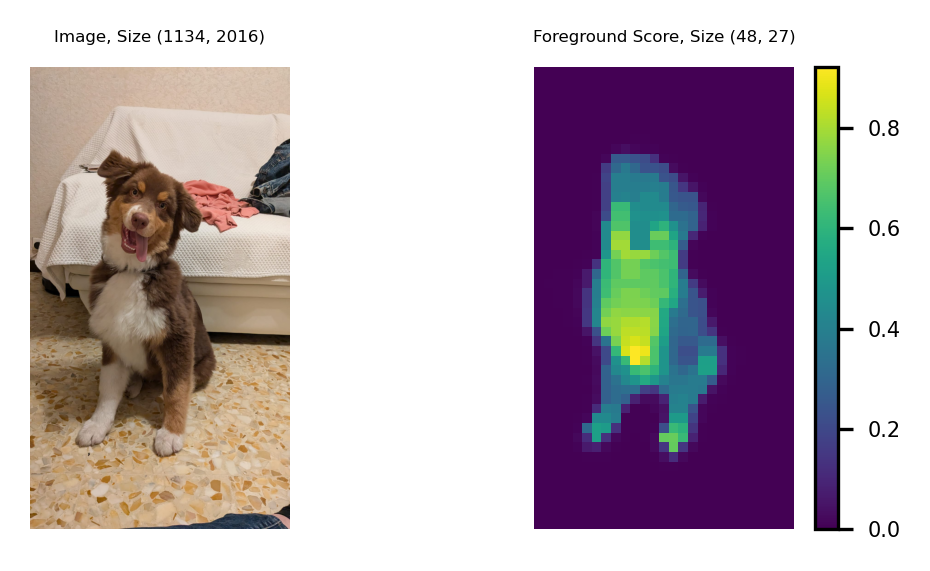

In [ ]:
h_patches, w_patches = [int(d / PATCH_SIZE) for d in image_resized.shape[1:]]

fg_score = clf.predict_proba(x)[:, 1].reshape(h_patches, w_patches)
fg_score_mf = torch.from_numpy(signal.medfilt2d(fg_score, kernel_size=3))

plt.rcParams.update({
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "axes.labelsize": 5,
    "axes.titlesize": 4,
})

plt.figure(figsize=(4, 2), dpi=300)
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis('off')
plt.title(f"Image, Size {image.size}")
plt.subplot(1, 2, 2)
plt.imshow(fg_score_mf)
plt.title(f"Foreground Score, Size {tuple(fg_score_mf.shape)}")
plt.colorbar()
plt.axis('off')
plt.show()

### Extracting Foreground Patches
We find the patches with positive classifier output, in order to fit the PCA only on the foreground.

In [ ]:
foreground_selection = fg_score_mf.view(-1) > 0.5
fg_patches = x[foreground_selection]

### Fitting the PCA
We use 3 components, and use whitening. 

In [ ]:
pca = PCA(n_components=3, whiten=True)
pca.fit(fg_patches)

,n_components,3
,copy,True
,whiten,True
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


### Applying the PCA, and Masking Background
Finally, we project the features using the PCA, and apply a mask to set the background to black.

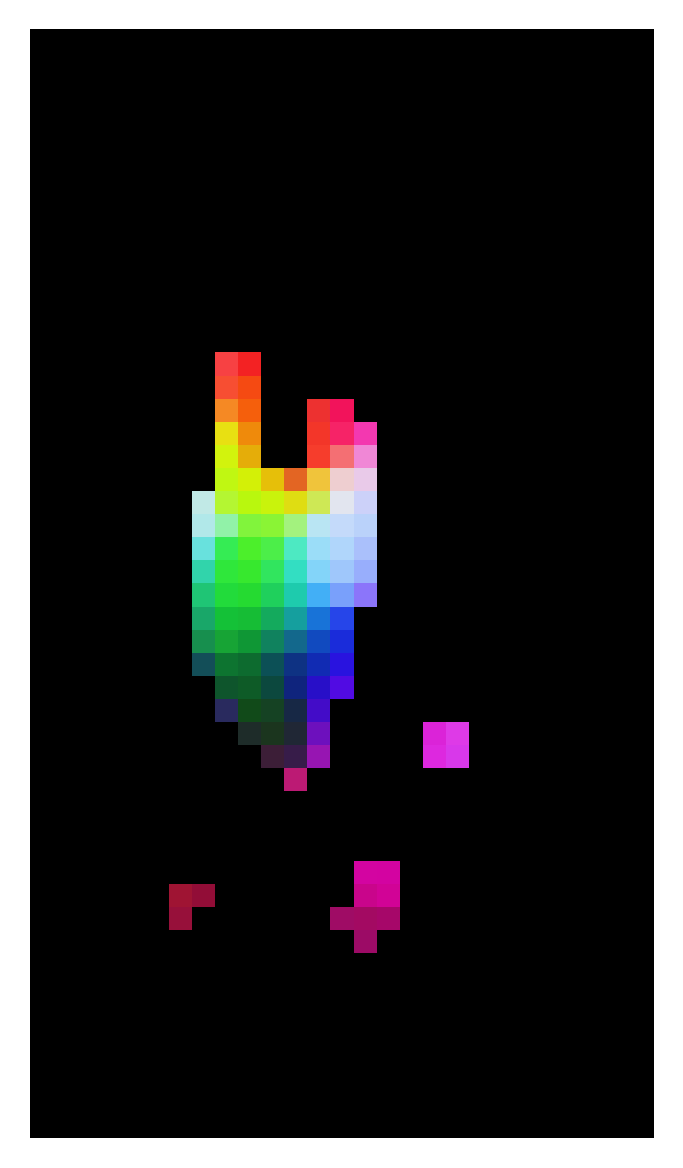

In [ ]:
# apply the PCA, and then reshape
projected_image = torch.from_numpy(pca.transform(x.numpy())).view(h_patches, w_patches, 3)

# multiply by 2.0 and pass through a sigmoid to get vibrant colors 
projected_image = torch.nn.functional.sigmoid(projected_image.mul(2.0)).permute(2, 0, 1)

# mask the background using the fg_score_mf
projected_image *= (fg_score_mf.unsqueeze(0) > 0.5)

# enjoy
plt.figure(dpi=300)
plt.imshow(projected_image.permute(1, 2, 0))
plt.axis('off')
plt.show()